# Embedding Exploration

This notebook explores how embeddings work by:
1. Loading sentence-transformers model
2. Embedding sample financial sentences
3. Computing cosine similarity between pairs
4. Visualizing which sentences are "close"

In [9]:
# Cell 1: Imports and Model Loading
from sentence_transformers import SentenceTransformer
import numpy as np
from numpy.linalg import norm

# Load embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')
print(f"Model loaded: all-MiniLM-L6-v2")
print(f"Embedding dimension: {model.get_sentence_embedding_dimension()}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 621.41it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded: all-MiniLM-L6-v2
Embedding dimension: 384


In [10]:
# Cell 2: Sample Financial Sentences
sentences = [
    # Similar meaning (revenue/sales growth)
    "Apple's revenue increased by 10%",
    "Apple's sales grew by 10 percent",
    "AAPL reported a 10% rise in revenue",

    # Different company
    "Microsoft announced new products",
    "Google launched a new service",

    # Risk-related
    "The company faces significant market risks",
    "There are substantial risks to the business",

    # Financial metrics
    "Net income was $5 billion",
    "Profit reached 5 billion dollars",
]

print("Sentences to embed:")
for i, s in enumerate(sentences):
    print(f"  [{i}] {s}")

Sentences to embed:
  [0] Apple's revenue increased by 10%
  [1] Apple's sales grew by 10 percent
  [2] AAPL reported a 10% rise in revenue
  [3] Microsoft announced new products
  [4] Google launched a new service
  [5] The company faces significant market risks
  [6] There are substantial risks to the business
  [7] Net income was $5 billion
  [8] Profit reached 5 billion dollars


In [11]:
# Cell 3: Generate Embeddings
embeddings = model.encode(sentences)

print(f"Embeddings shape: {embeddings.shape}")
print(f"Each sentence -> {embeddings.shape[1]}-dimensional vector")
print(f"\nFirst embedding (first 10 values): {embeddings[0][:10]}")

Embeddings shape: (9, 384)
Each sentence -> 384-dimensional vector

First embedding (first 10 values): [ 0.02472261 -0.04230577  0.02941521 -0.07977926  0.04609815 -0.01508638
  0.0599465   0.06078081  0.01474133  0.0490562 ]


In [12]:
# Cell 4: Cosine Similarity Function
def cosine_similarity(vec1, vec2):
    """Calculate cosine similarity between two vectors."""
    return np.dot(vec1, vec2) / (norm(vec1) * norm(vec2))

# Test similarity between first two sentences (should be HIGH)
sim = cosine_similarity(embeddings[0], embeddings[1])
print(f'Similarity between:')
print(f'  "{sentences[0]}"')
print(f'  "{sentences[1]}"')
print(f'  Score: {sim:.4f}')

# Test similarity between different topics (should be LOW)
sim2 = cosine_similarity(embeddings[0], embeddings[3])
print(f'\nSimilarity between:')
print(f'  "{sentences[0]}"')
print(f'  "{sentences[3]}"')
print(f'  Score: {sim2:.4f}')

Similarity between:
  "Apple's revenue increased by 10%"
  "Apple's sales grew by 10 percent"
  Score: 0.8641

Similarity between:
  "Apple's revenue increased by 10%"
  "Microsoft announced new products"
  Score: 0.2829


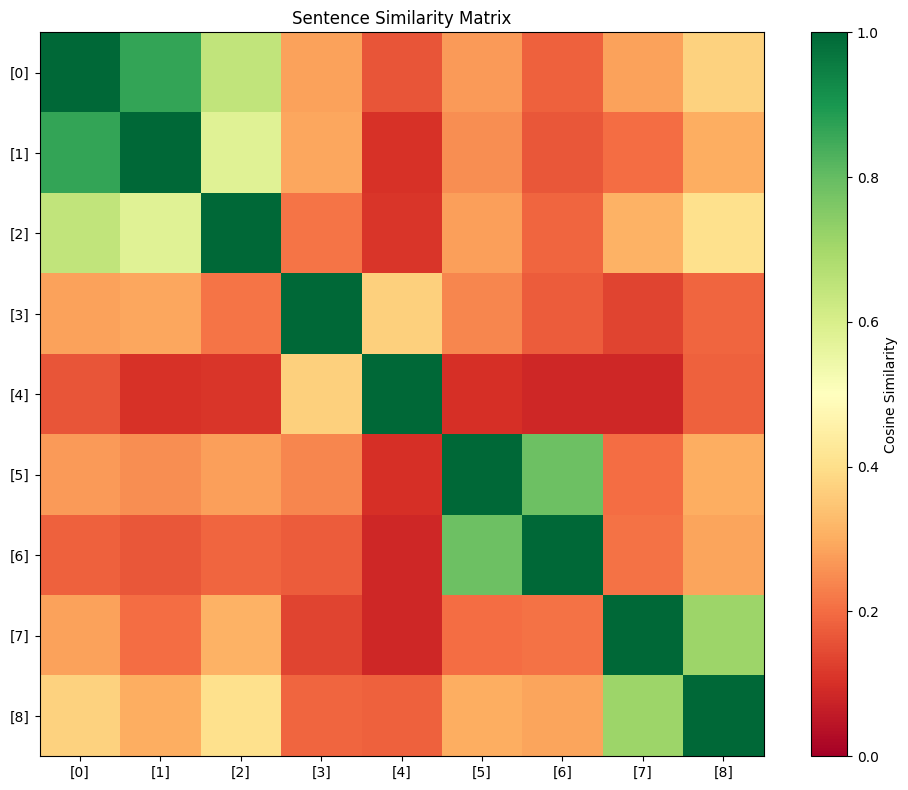


Legend:
  [0] Apple's revenue increased by 10%
  [1] Apple's sales grew by 10 percent
  [2] AAPL reported a 10% rise in revenue
  [3] Microsoft announced new products
  [4] Google launched a new service
  [5] The company faces significant market risks
  [6] There are substantial risks to the business
  [7] Net income was $5 billion
  [8] Profit reached 5 billion dollars


In [13]:
# Cell 5: Similarity Matrix Heatmap
import matplotlib.pyplot as plt

# Calculate similarity matrix
n = len(sentences)
similarity_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        similarity_matrix[i][j] = cosine_similarity(embeddings[i], embeddings[j])

# Display as heatmap
plt.figure(figsize=(10, 8))
plt.imshow(similarity_matrix, cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(label='Cosine Similarity')
plt.xticks(range(n), [f'[{i}]' for i in range(n)])
plt.yticks(range(n), [f'[{i}]' for i in range(n)])
plt.title('Sentence Similarity Matrix')
plt.tight_layout()
plt.show()

print("\nLegend:")
for i, s in enumerate(sentences):
    print(f"  [{i}] {s}")

In [14]:
# Cell 6: Find Most Similar Pairs
pairs = []
for i in range(n):
    for j in range(i+1, n):
        pairs.append((i, j, similarity_matrix[i][j]))

# Sort by similarity
pairs.sort(key=lambda x: x[2], reverse=True)

print("Top 5 Most Similar Pairs:")
print("=" * 60)
for i, j, sim in pairs[:5]:
    print(f"Score: {sim:.4f}")
    print(f"  [{i}] {sentences[i]}")
    print(f"  [{j}] {sentences[j]}")
    print()

Top 5 Most Similar Pairs:
Score: 0.8641
  [0] Apple's revenue increased by 10%
  [1] Apple's sales grew by 10 percent

Score: 0.7856
  [5] The company faces significant market risks
  [6] There are substantial risks to the business

Score: 0.7131
  [7] Net income was $5 billion
  [8] Profit reached 5 billion dollars

Score: 0.6456
  [0] Apple's revenue increased by 10%
  [2] AAPL reported a 10% rise in revenue

Score: 0.5794
  [1] Apple's sales grew by 10 percent
  [2] AAPL reported a 10% rise in revenue



In [15]:
# Cell 7: Test with Real Chunk Data
import json
from pathlib import Path

# Load a processed chunk file
chunk_file = Path("../data/processed/AAPL_chunks.json")
if chunk_file.exists():
    with open(chunk_file) as f:
        data = json.load(f)

    # Get first 5 chunks
    sample_chunks = [c["text"][:200] for c in data["chunks"][:5]]

    # Embed and compare
    chunk_embeddings = model.encode(sample_chunks)

    print("Sample chunks from AAPL filing:")
    for i, chunk in enumerate(sample_chunks):
        print(f"[{i}] {chunk[:100]}...")

    # Calculate similarities
    print("\nChunk similarities:")
    for i in range(len(sample_chunks)):
        for j in range(i+1, len(sample_chunks)):
            sim = cosine_similarity(chunk_embeddings[i], chunk_embeddings[j])
            print(f"  [{i}] vs [{j}]: {sim:.4f}")
else:
    print(f"Chunk file not found: {chunk_file}")
    print("Run 'python scripts/process_documents.py' first to generate chunks.")

Sample chunks from AAPL filing:
[0] UNITED STATES
SECURITIES AND EXCHANGE COMMISSION
Washington, D.C. 20549
FORM 10-K
(Mark One)
☒ ANNUA...
[1] California 94-2404110
(State or other jurisdictionof incorporation or organization) (I.R.S. Employer...
[2] Common Stock, $0.00001 par value per shareAAPL The Nasdaq Stock Market LLC
0.000% Notes due 2025 — T...
[3] Securities registered pursuant to Section 12(g) of the Act: None
Indicate by check mark if the Regis...
[4] Indicate by check mark if the Registrant is not required to file reports pursuant to Section 13 or S...

Chunk similarities:
  [0] vs [1]: 0.2870
  [0] vs [2]: 0.3874
  [0] vs [3]: 0.4628
  [0] vs [4]: 0.4239
  [1] vs [2]: 0.0748
  [1] vs [3]: 0.2649
  [1] vs [4]: 0.2585
  [2] vs [3]: 0.1925
  [2] vs [4]: 0.0779
  [3] vs [4]: 0.6348


In [16]:
# Cell 8: Compare Embedding Models
models_to_compare = {
    'MiniLM (fast)': 'all-MiniLM-L6-v2',
    'MPNet (quality)': 'all-mpnet-base-v2'
}

test_sentences = [
    "Apple's revenue increased significantly",
    "Apple's sales grew substantially",
    "Microsoft released new software"
]

print("Model Comparison:")
print("=" * 60)
for name, model_id in models_to_compare.items():
    m = SentenceTransformer(model_id)
    emb = m.encode(test_sentences)

    sim_01 = cosine_similarity(emb[0], emb[1])  # Similar
    sim_02 = cosine_similarity(emb[0], emb[2])  # Different

    print(f"\n{name} ({m.get_sentence_embedding_dimension()} dims):")
    print(f"  Similar sentences:   {sim_01:.4f}")
    print(f"  Different sentences: {sim_02:.4f}")
    print(f"  Discrimination: {sim_01 - sim_02:.4f}")

Model Comparison:


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 596.82it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



MiniLM (fast) (384 dims):
  Similar sentences:   0.8339
  Different sentences: 0.2400
  Discrimination: 0.5939


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 690.75it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



MPNet (quality) (768 dims):
  Similar sentences:   0.8964
  Different sentences: 0.1940
  Discrimination: 0.7024


## Conclusion:

1. Embeddings work as expected: Semantically similar sentences cluster together (similarity > 0.7), while unrelated sentences stay apart (< 0.5)

2. Synonym handling is strong: "revenue/sales", "increased/grew", "net income/profit" are correctly recognized as equivalent

3. Ticker symbols reduce similarity: "AAPL" vs "Apple" causes a ~25% drop in similarity score. Consider normalizing tickers to company names in preprocessing

4. Model recommendation:

    1. Use MiniLM for development/testing (faster, 384 dims)
    2. Consider MPNet for production if retrieval precision is critical (better discrimination but 2x embedding size)
5. Chunking insight: The first 5 chunks from the SEC filing are all boilerplate headers with low inter-similarity. The actual financial content (revenue, risks, metrics) will likely have better retrieval characteristics